# Round 2 Initial Product Analysis

**Same notebook as Round 1 with only datasource changed**

This notebook performs an initial exploratory analysis for the two Round 1 products.

Goals:
1. Load and combine all price/trade files
2. Separate the two products
3. Analyze price behavior for each product
4. Look for structure, stationarity, mean reversion, jumps, and predictive signals
5. Build intuition for possible trading strategies


In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (12,5)

def round2_data_dir() -> Path:
    cwd = Path.cwd()
    for base in (cwd, cwd.parent):
        p = base / "data" / "ROUND_2"
        if p.is_dir():
            return p
    raise FileNotFoundError(
        f"找不到 data/ROUND2，当前工作目录: {cwd.resolve()}。"
        "请从 88-Pineapple 仓库根目录启动内核，或在笔记本里 os.chdir 到仓库根。"
    )

DATA = round2_data_dir()
days = (-1, 0, 1)
price_files = [DATA / f"prices_round_2_day_{d}.csv" for d in days]
trade_files = [DATA / f"trades_round_2_day_{d}.csv" for d in days]

prices = pd.concat([pd.read_csv(f, sep=";") for f in price_files], ignore_index=True)
trades = pd.concat(
    [pd.read_csv(f, sep=";").assign(day=d) for d, f in zip(days, trade_files)],
    ignore_index=True,
)

print(prices.columns)
print(trades.columns)
print(prices["product"].unique())


Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss'],
      dtype='object')
Index(['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price',
       'quantity', 'day'],
      dtype='object')
['INTARIAN_PEPPER_ROOT' 'ASH_COATED_OSMIUM']


### Purpose
- Identify the exact Round 1 products present in the dataset.
- Split both price data and trade data into per-product dataframes for downstream analysis.

### Expected Result
- We should end up with one clean price dataframe and one clean trade dataframe for each product.
- All later sections should be able to refer to products directly by name.

### Intuition
- Most later diagnostics are product-specific, so the notebook should organize data around the true product identities from the start.
- This also prevents accidental mixing of price and trade records across products.

### Steps
1. Confirm the two product names in the raw files.
2. Build product-keyed dictionaries for prices and trades.
3. Expose direct variables for the two products for easier reference.


# 1. Split by Product

The two Round 1 products in this dataset are:
- `INTARIAN_PEPPER_ROOT`
- `ASH_COATED_OSMIUM`

We split both the price data and trade data by these exact product names.


### Purpose
- Build the core price features used throughout the notebook.
- Create a consistent `mid`, `spread`, and `mid_diff` series for both products.

### Expected Result
- Each product dataframe should contain a usable `mid`, `spread`, and `mid_diff` column.
- Missing best bid or best ask quotes should not break the main price series.

### Intuition
- The raw files already include `mid_price`, which is safer than recomputing from top-of-book quotes when one side is missing.
- Mid differences and spread are the minimum ingredients needed to study flatness, drift, mean reversion, and microstructure behavior.

### Steps
1. Sort each product by `day` and `timestamp`.
2. Use `mid_price` as the main mid series, with bid/ask fallback only if needed.
3. Build `spread`, `mid_diff`, and a monotonic time index for later diagnostics.


In [103]:
# 按产品名保存为不同 dataframe，后续可直接用产品名索引。
price_by_product = {
    product: df.copy()
    for product, df in prices.groupby("product")
}

trade_by_product = {
    product: df.copy()
    for product, df in trades.groupby("symbol")
}

print("Price products:", list(price_by_product))
for product, df in price_by_product.items():
    print(product, len(df))

print("\nExample access:")
print(price_by_product[list(price_by_product)[0]].head(2))


Price products: ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']
ASH_COATED_OSMIUM 30000
INTARIAN_PEPPER_ROOT 30000

Example access:
   day  timestamp            product  ...  ask_volume_3  mid_price  profit_and_loss
1   -1          0  ASH_COATED_OSMIUM  ...           NaN     9991.0              0.0
2   -1        100  ASH_COATED_OSMIUM  ...           NaN     9992.0              0.0

[2 rows x 17 columns]


# 2. Overview Plot

Before building derived features, we first inspect the raw market activity.

For each product, this section overlays:
- best bid
- best ask
- trade price prints
- aggregated trade volume

This gives a fast visual sense of how quotes and executed flow evolve together over time.


### Purpose
- Provide a quick per-product market overview before the deeper diagnostics.
- Compare top-of-book prices against executed trades on the same time axis.
- Show when volume clusters occur relative to bid/ask movement.

### Expected Result
- Each product should have one readable overview chart.
- Best bid / best ask should frame the visible trading range.
- Trade price points and volume spikes should reveal whether activity concentrates around specific quote changes.

### Intuition
- A product can look very different once quotes and prints are viewed together.
- Volume bursts near one side of the book can hint at pressure, while quiet prints suggest passive flow.

### Steps
1. Sort price and trade records by `day` and `timestamp`.
2. Build a shared monotonic x-axis from the price timestamps.
3. Plot best bid, best ask, trade price, and trade volume for each product.
4. Use the chart as a high-level orientation before formal analysis.

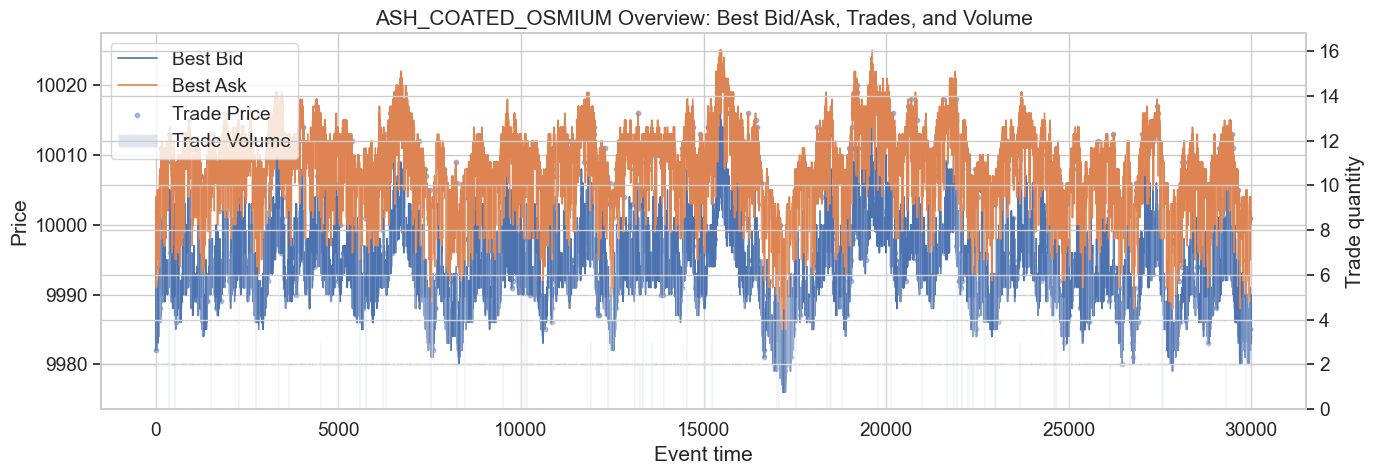

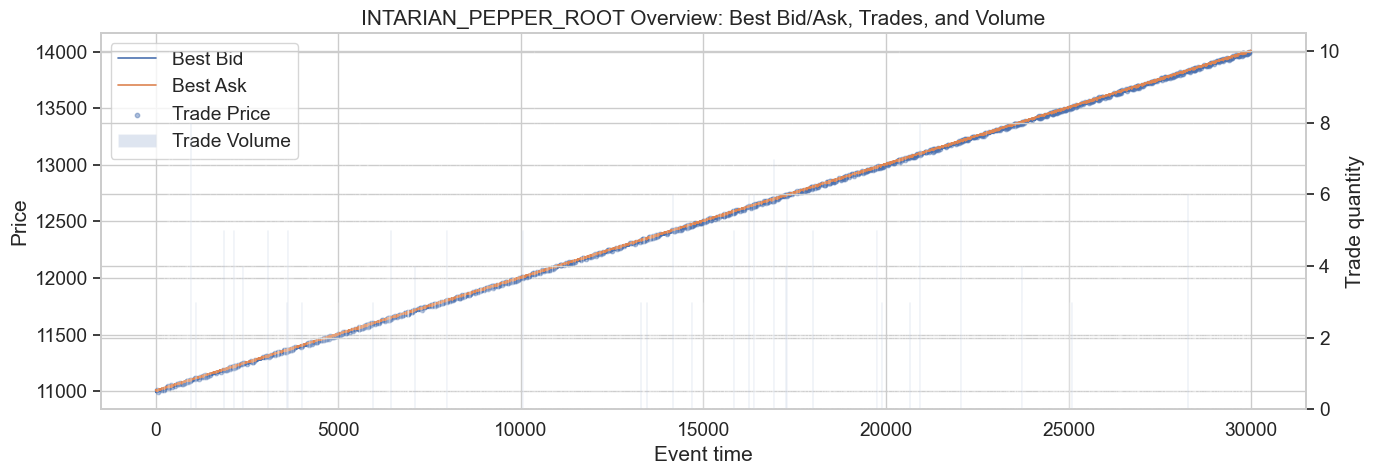

In [78]:
for product, price_df in price_by_product.items():
    price_df = price_df.sort_values(["day", "timestamp"]).reset_index(drop=True).copy()
    trade_df = (
        trade_by_product[product]
        .sort_values(["day", "timestamp"])
        .reset_index(drop=True)
        .copy()
    )

    time_points = (
        price_df[["day", "timestamp"]]
        .drop_duplicates()
        .sort_values(["day", "timestamp"])
        .reset_index(drop=True)
    )
    time_points["plot_time"] = np.arange(len(time_points))

    price_plot = price_df.merge(time_points, on=["day", "timestamp"], how="left")
    trade_plot = trade_df.merge(time_points, on=["day", "timestamp"], how="left")
    volume_plot = (
        trade_plot.groupby("plot_time", as_index=False)["quantity"]
        .sum()
        .rename(columns={"quantity": "total_quantity"})
    )

    fig, ax_price = plt.subplots(figsize=(14, 5))
    ax_volume = ax_price.twinx()

    ax_price.plot(price_plot["plot_time"], price_plot["bid_price_1"], label="Best Bid", linewidth=1.2)
    ax_price.plot(price_plot["plot_time"], price_plot["ask_price_1"], label="Best Ask", linewidth=1.2)
    ax_price.scatter(
        trade_plot["plot_time"],
        trade_plot["price"],
        s=10,
        alpha=0.45,
        label="Trade Price",
    )

    ax_volume.bar(
        volume_plot["plot_time"],
        volume_plot["total_quantity"],
        width=1.0,
        alpha=0.18,
        label="Trade Volume",
    )

    ax_price.set_title(f"{product} Overview: Best Bid/Ask, Trades, and Volume")
    ax_price.set_xlabel("Event time")
    ax_price.set_ylabel("Price")
    ax_volume.set_ylabel("Trade quantity")

    handles_price, labels_price = ax_price.get_legend_handles_labels()
    handles_volume, labels_volume = ax_volume.get_legend_handles_labels()
    ax_price.legend(handles_price + handles_volume, labels_price + labels_volume, loc="upper left")

    plt.tight_layout()
    plt.show()

    

In [79]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Use plotly to enable zoom, enlarge and interactivity for one product as an example.
# You can loop for each product if you want all interactive.

for product in price_by_product.keys():
    price_df = price_by_product[product].reset_index(drop=True)
    trade_df = trade_by_product[product].reset_index(drop=True)

    # Create a matching time axis for trade data if available
    if "timestamp" in trade_df.columns and "day" in trade_df.columns:
        trade_plot = trade_df.merge(
            price_df[["day", "timestamp"]].reset_index().rename(columns={'index': 'plot_time'}),
            on=["day", "timestamp"],
            how="left"
        )
    else:
        trade_plot = trade_df.copy()
        trade_plot["plot_time"] = np.arange(len(trade_plot))

    # Volume per event
    if "plot_time" in trade_plot.columns:
        volume_plot = (
            trade_plot.groupby("plot_time", as_index=False)["quantity"]
            .sum()
            .rename(columns={"quantity": "total_quantity"})
        )
    else:
        volume_plot = pd.DataFrame({"plot_time": [], "total_quantity": []})

    fig = make_subplots(specs=[[{"secondary_y": True}]])
    
    # Plot best bid/ask lines
    fig.add_trace(
        go.Scatter(
            x=price_df.index,
            y=price_df["bid_price_1"],
            mode="lines",
            name="Best Bid",
            line=dict(width=1.3, color="green"),
            hovertemplate="Event: %{x}<br>Bid: %{y}"
        ),
        secondary_y=False,
    )
    fig.add_trace(
        go.Scatter(
            x=price_df.index,
            y=price_df["ask_price_1"],
            mode="lines",
            name="Best Ask",
            line=dict(width=1.3, color="red"),
            hovertemplate="Event: %{x}<br>Ask: %{y}"
        ),
        secondary_y=False,
    )
    # Plot trade prices as togglable points
    fig.add_trace(
        go.Scatter(
            x=trade_plot["plot_time"],
            y=trade_plot["price"],
            mode="markers",
            name="Trade Price",
            marker=dict(size=6, opacity=0.5, color="blue"),
            hovertemplate="Trade Event: %{x}<br>Price: %{y}",
            visible=True  # allow toggling legend
        ),
        secondary_y=False,
    )
    # Plot trade volume (as bars, to toggle via legend)
    fig.add_trace(
        go.Bar(
            x=volume_plot["plot_time"] if not volume_plot.empty else [],
            y=volume_plot["total_quantity"] if not volume_plot.empty else [],
            opacity=0.2,
            marker_color="gray",
            name="Trade Volume",
            hovertemplate="Event: %{x}<br>Volume: %{y}",
        ),
        secondary_y=True,
    )

    # Layout with titles and interactivity
    fig.update_layout(
        title=f"{product} Overview (Interactive): Best Bid/Ask, Trades, and Volume",
        xaxis_title="Event time",
        yaxis_title="Price",
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1,
            font=dict(size=13),
        ),
        height=550,
        width=1050,
        margin=dict(l=40, r=20, t=50, b=40)
    )
    fig.update_yaxes(title_text="Trade Quantity", secondary_y=True)
    fig.update_xaxes(rangeslider_visible=True)
    
    fig.show()

# 3. Price Construction

We construct:
- mid price = (best bid + best ask) / 2
- spread = best ask - best bid

These are the main series to study.


In [104]:
for product, df in price_by_product.items():
    df = df.sort_values(["day", "timestamp"]).reset_index(drop=True).copy()

    if "mid_price" in df.columns:
        df["mid"] = df["mid_price"]
        missing_mid = df["mid"].isna()
        if missing_mid.any():
            df.loc[missing_mid, "mid"] = (
                df.loc[missing_mid, "bid_price_1"] + df.loc[missing_mid, "ask_price_1"]
            ) / 2
    else:
        df["mid"] = (df["bid_price_1"] + df["ask_price_1"]) / 2

    df["spread"] = df["ask_price_1"] - df["bid_price_1"]
    df["mid_diff"] = df["mid"].diff()
    df["global_time"] = np.arange(len(df))
    price_by_product[product] = df

pepper_prices = price_by_product["INTARIAN_PEPPER_ROOT"]
osmium_prices = price_by_product["ASH_COATED_OSMIUM"]


# 4. Price Analysis by Product

For both `INTARIAN_PEPPER_ROOT` and `ASH_COATED_OSMIUM`:
- Plot price through time
- Plot spread
- Look at `mid_diff` distribution
- Compute simple autocorrelation


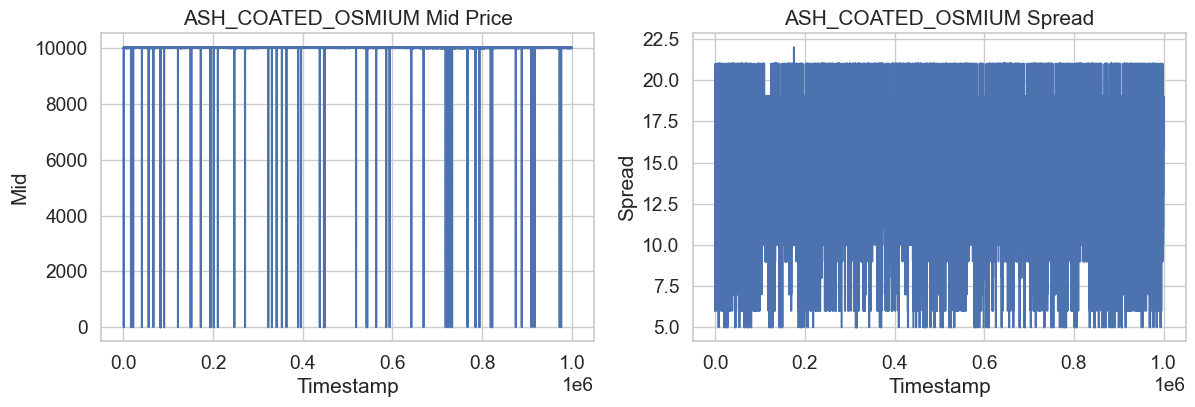

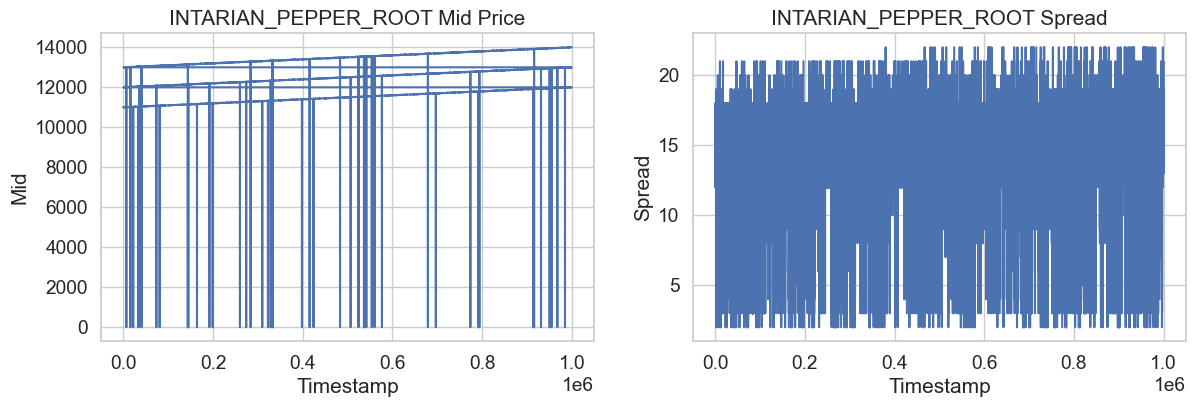

In [81]:
for product, df in price_by_product.items():
    fig, axes = plt.subplots(1, 2, figsize=(14,4))
    
    axes[0].plot(df["timestamp"], df["mid"])
    axes[0].set_title(f"{product} Mid Price")
    axes[0].set_xlabel("Timestamp")
    axes[0].set_ylabel("Mid")
    
    axes[1].plot(df["timestamp"], df["spread"])
    axes[1].set_title(f"{product} Spread")
    axes[1].set_xlabel("Timestamp")
    axes[1].set_ylabel("Spread")
    
    plt.show()


In [82]:
for product, df in price_by_product.items():
    num_positive = (df["mid_diff"] > 0).sum()
    num_negative = (df["mid_diff"] < 0).sum()
    print(f"{product}: mid_diff > 0: {num_positive}, mid_diff < 0: {num_negative}")

ASH_COATED_OSMIUM: mid_diff > 0: 10843, mid_diff < 0: 10832
INTARIAN_PEPPER_ROOT: mid_diff > 0: 11115, mid_diff < 0: 8486


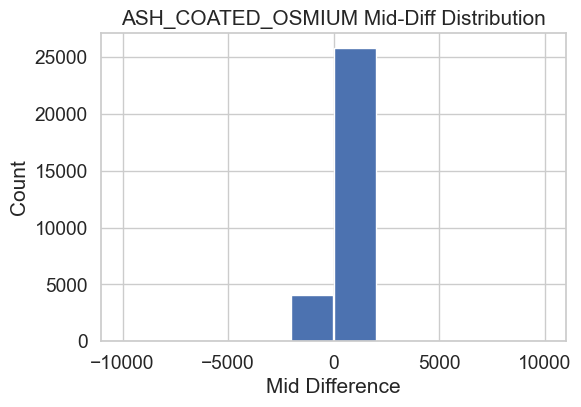

ASH_COATED_OSMIUM: lag1 mid_diff autocorr = -0.5000, lag5 mid_diff autocorr = 0.0189


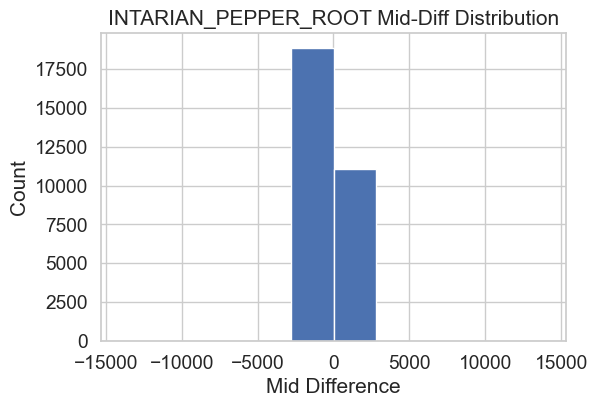

INTARIAN_PEPPER_ROOT: lag1 mid_diff autocorr = -0.5106, lag5 mid_diff autocorr = 0.0000


In [83]:
for product, df in price_by_product.items():
    plt.figure(figsize=(6,4))
    plt.hist(df["mid_diff"].dropna())
    plt.title(f"{product} Mid-Diff Distribution")
    plt.xlabel("Mid Difference")
    plt.ylabel("Count")
    plt.show()

    ac1 = df["mid_diff"].autocorr(lag=1)
    ac5 = df["mid_diff"].autocorr(lag=5)
    
    print(f"{product}: lag1 mid_diff autocorr = {ac1:.4f}, lag5 mid_diff autocorr = {ac5:.4f}")


### Purpose
- Run a lightweight diagnostic on whether each product looks flat, mean reverting, or trending.
- Prepare the notebook for the deeper product-specific sections that follow.

### Expected Result
- A stable rolling mean supports a more constant-value interpretation.
- A visibly moving rolling mean suggests drift, trend, or regime change.
- Strong short-horizon snapback would support mean reversion rather than random walk.

### Intuition
- A rolling mean is not a formal test, but it is a fast way to separate short-lived noise from slower structural movement.
- If the rolling mean itself moves materially, the product is unlikely to be truly constant.

### Steps
1. Overlay `mid` with a rolling mean for each product.
2. Compare the gap between short-run fluctuations and the slower baseline.
3. Use this as a bridge into the two product-specific diagnostics below.


# 5. Mean-Reversion vs Trending

A useful first check:

- If the product is nearly flat around one level, it may have a fixed fair value
- If it wanders but snaps back, it may be mean reverting
- If short-term `mid_diff` has negative autocorrelation, market making may work well
- If `mid_diff` has positive autocorrelation, momentum may exist


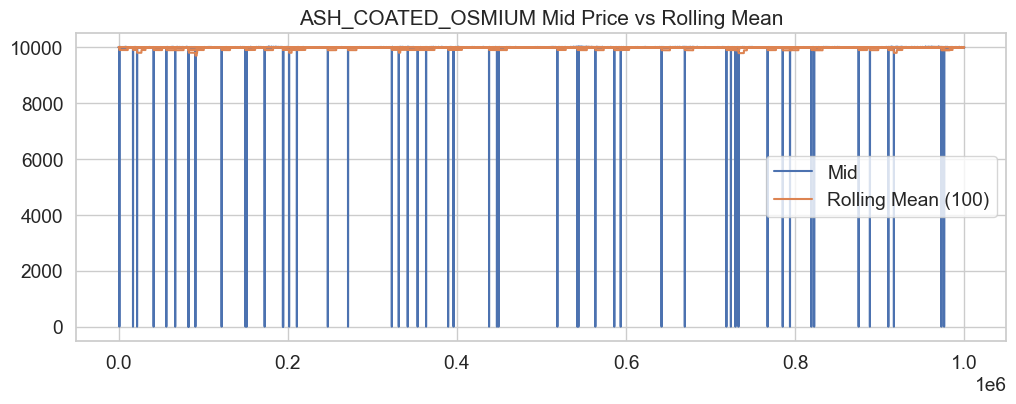

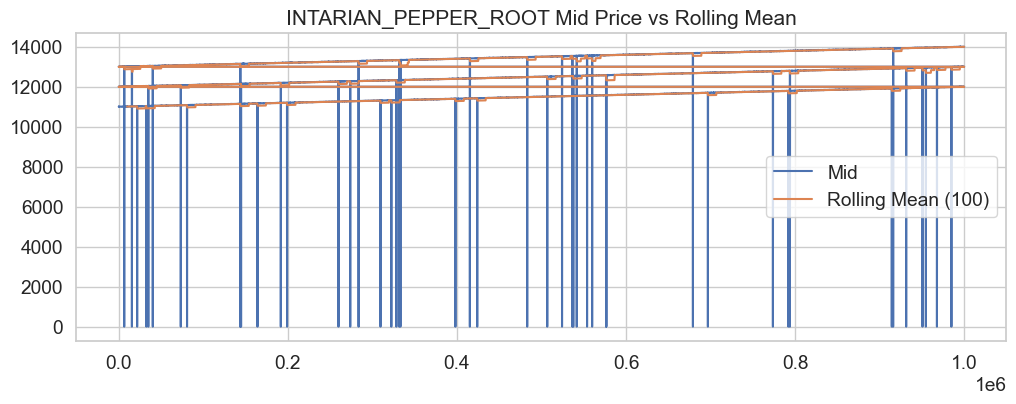

In [84]:
for product, df in price_by_product.items():
    rolling_mean = df["mid"].rolling(100).mean()
    
    plt.figure(figsize=(12,4))
    plt.plot(df["timestamp"], df["mid"], label="Mid")
    plt.plot(df["timestamp"], rolling_mean, label="Rolling Mean (100)")
    plt.title(f"{product} Mid Price vs Rolling Mean")
    plt.legend()
    plt.show()


# 6. `ASH_COATED_OSMIUM` Flat Price vs Random Walk

### Purpose
- Test whether `ASH_COATED_OSMIUM` behaves like a nearly flat price with a small random-walk component.
- Distinguish random walk from stable-noisy price action and weak mean reversion.

### Expected Result
- Stable rolling mean and narrow day-level ranges support a flat-price view.
- Diffusion-like noise with little pullback supports a random-walk view.
- Clear pullback after deviations and negative short-lag mid-diff autocorrelation argue against random walk and in favor of mean reversion.

### Intuition
- A true random walk can drift away from its starting level without repeatedly snapping back to the same center.
- A flat product should keep revisiting a narrow value region and should not show persistent drift in its rolling mean.

### Steps
1. Plot `mid` using the full sample and split by `day`.
2. Plot `mid_diff` and inspect its shape.
3. Compute multi-lag autocorrelation.
4. Compare rolling mean and rolling standard deviation over time.
5. Summarize day-level mean, standard deviation, and range.
6. Write down whether the evidence supports flatness, random walk, or mean reversion.


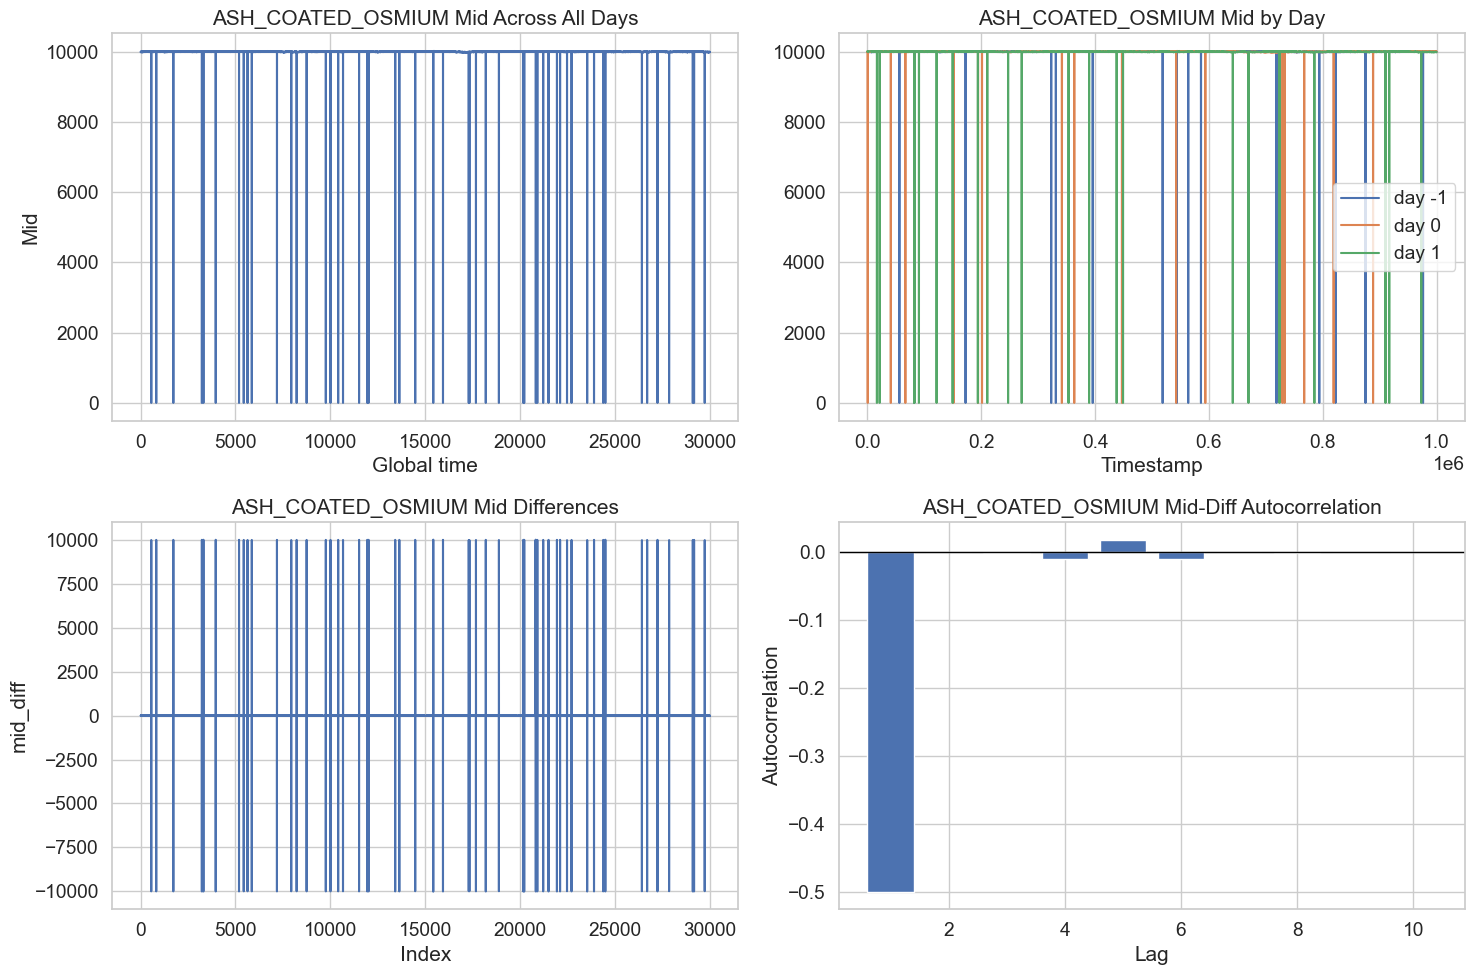

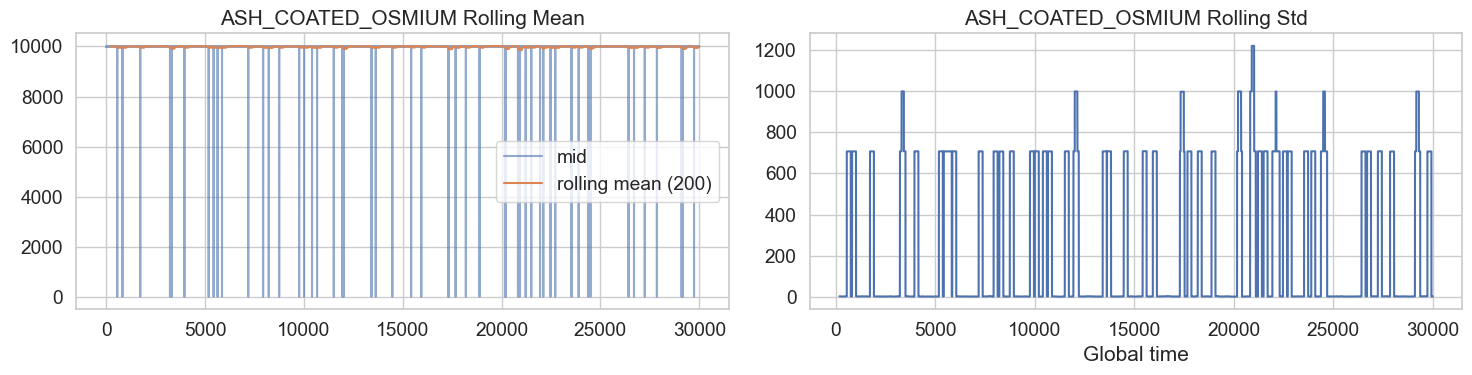

ASH_COATED_OSMIUM day summary
      mid_mean   mid_std  mid_min  mid_max  mid_range
day                                                  
-1   9985.8238  387.0848      0.0  10020.0    10020.0
 0   9985.6048  399.8041      0.0  10023.0    10023.0
 1   9978.2050  468.5852      0.0  10019.0    10019.0

ASH_COATED_OSMIUM mid_diff autocorrelation
1    -0.5000
2     0.0001
3    -0.0001
4    -0.0094
5     0.0189
6    -0.0094
7     0.0000
8    -0.0001
9     0.0000
10    0.0001
dtype: float64

Overall mean/std/range
mean     9983.211200
std       420.020785
min         0.000000
max     10023.000000
Name: mid, dtype: float64


In [85]:
# ASH_COATED_OSMIUM diagnostic code
osmium = price_by_product["ASH_COATED_OSMIUM"].copy()
osmium_mid_diff = osmium["mid_diff"].dropna()
lag_autocorr = {lag: osmium_mid_diff.autocorr(lag=lag) for lag in range(1, 11)}
day_summary = (
    osmium.groupby("day")
    .agg(mid_mean=("mid", "mean"), mid_std=("mid", "std"), mid_min=("mid", "min"), mid_max=("mid", "max"))
)
day_summary["mid_range"] = day_summary["mid_max"] - day_summary["mid_min"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0, 0].plot(osmium["global_time"], osmium["mid"])
axes[0, 0].set_title("ASH_COATED_OSMIUM Mid Across All Days")
axes[0, 0].set_xlabel("Global time")
axes[0, 0].set_ylabel("Mid")

for day, sub in osmium.groupby("day"):
    axes[0, 1].plot(sub["timestamp"], sub["mid"], label=f"day {day}")
axes[0, 1].set_title("ASH_COATED_OSMIUM Mid by Day")
axes[0, 1].set_xlabel("Timestamp")
axes[0, 1].legend()

axes[1, 0].plot(osmium_mid_diff.index, osmium_mid_diff.values)
axes[1, 0].set_title("ASH_COATED_OSMIUM Mid Differences")
axes[1, 0].set_xlabel("Index")
axes[1, 0].set_ylabel("mid_diff")

axes[1, 1].bar(list(lag_autocorr.keys()), list(lag_autocorr.values()))
axes[1, 1].axhline(0, color="black", linewidth=1)
axes[1, 1].set_title("ASH_COATED_OSMIUM Mid-Diff Autocorrelation")
axes[1, 1].set_xlabel("Lag")
axes[1, 1].set_ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

rolling_window = 200
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(osmium["global_time"], osmium["mid"], alpha=0.6, label="mid")
axes[0].plot(osmium["global_time"], osmium["mid"].rolling(rolling_window).mean(), label=f"rolling mean ({rolling_window})")
axes[0].set_title("ASH_COATED_OSMIUM Rolling Mean")
axes[0].legend()

axes[1].plot(osmium["global_time"], osmium["mid"].rolling(rolling_window).std())
axes[1].set_title("ASH_COATED_OSMIUM Rolling Std")
axes[1].set_xlabel("Global time")
plt.tight_layout()
plt.show()

print("ASH_COATED_OSMIUM day summary")
print(day_summary.round(4))
print("\nASH_COATED_OSMIUM mid_diff autocorrelation")
print(pd.Series(lag_autocorr).round(4))
print("\nOverall mean/std/range")
print(osmium["mid"].agg(["mean", "std", "min", "max"]))


### Interpretation
- If `ASH_COATED_OSMIUM` keeps revisiting a narrow center and the rolling mean stays fairly stable, that is evidence for a mostly flat product.
- If short-lag `mid_diff` autocorrelation is meaningfully negative, that is evidence against a pure random walk and more in favor of mean reversion or microstructure bounce.
- If day-level means are similar but day-level ranges stay narrow, the product is likely better described as stable with noise rather than as a drifting asset.
- Strategy intuition: flat-and-stable behavior is usually more compatible with market making than with long-horizon directional bets.


# 7. Large Order / Wall Price Analysis

### Purpose
- Compare ordinary mid with wall-based mid for each product.
- Check whether deeper visible liquidity carries extra information beyond the best bid and ask.

### Expected Result
- If wall-based mid closely tracks future price better than ordinary mid, it may contain predictive information.
- If wall-based mid behaves similarly to ordinary mid, it likely adds little incremental signal.

### Intuition
- The largest displayed size can act like a stronger reference level than the best quote alone.
- This matters most when one side of the book is thin or when large visible orders anchor short-term price movement.

### Steps
1. Identify the largest visible bid and ask levels.
2. Build a wall-based mid.
3. Compare wall mid against ordinary mid visually.
4. Use the comparison as a signal-screening step rather than a final proof.


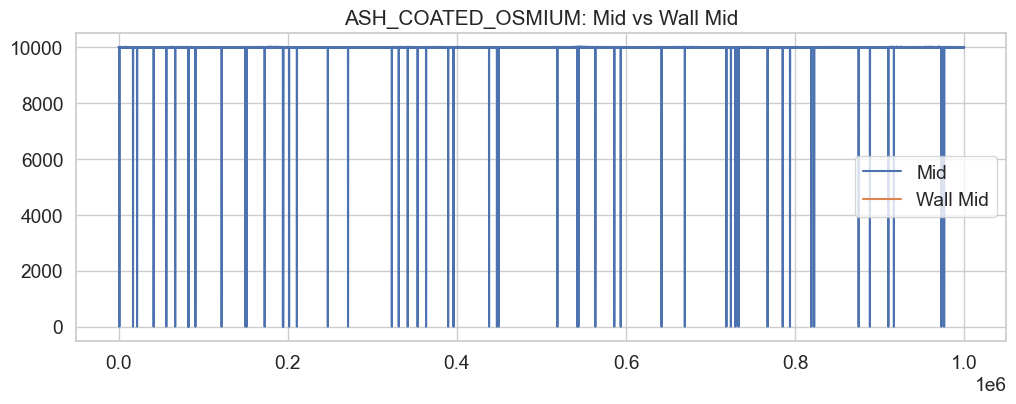

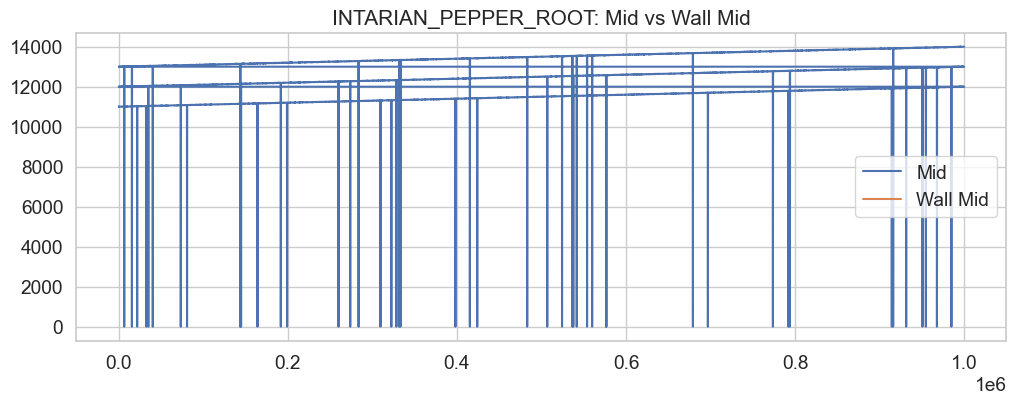

In [86]:
for product, df in price_by_product.items():
    bid_prices = [c for c in df.columns if "bid_price" in c]
    bid_sizes = [c for c in df.columns if "bid_volume" in c]
    ask_prices = [c for c in df.columns if "ask_price" in c]
    ask_sizes = [c for c in df.columns if "ask_volume" in c]

    if len(bid_prices) >= 3:
        def wall_bid(row):
            idx = np.argmax([row[v] for v in bid_sizes])
            return row[bid_prices[idx]]

        def wall_ask(row):
            idx = np.argmax([abs(row[v]) for v in ask_sizes])
            return row[ask_prices[idx]]

        df = df.copy()
        df["wall_bid"] = df.apply(wall_bid, axis=1)
        df["wall_ask"] = df.apply(wall_ask, axis=1)
        df["wall_mid"] = (df["wall_bid"] + df["wall_ask"]) / 2
        price_by_product[product] = df

        plt.figure(figsize=(12,4))
        plt.plot(df["timestamp"], df["mid"], label="Mid")
        plt.plot(df["timestamp"], df["wall_mid"], label="Wall Mid")
        plt.title(f"{product}: Mid vs Wall Mid")
        plt.legend()
        plt.show()


# 8. `INTARIAN_PEPPER_ROOT` Constant Value vs Slow Drift

### Purpose
- Test whether `INTARIAN_PEPPER_ROOT` is truly centered around a constant value.
- If not, determine whether the series looks like slow drift, a directional process, or a step-like regime change.

### Expected Result
- A nearly flat long-window baseline supports a constant-value interpretation.
- A persistently moving long-window baseline and non-zero time trend support a slow-changing process.
- Sharp jumps between levels support regime change more than smooth drift.

### Intuition
- A constant-value asset should not keep moving its long-run center over time.
- If the long-window mean shifts, then what looks noisy locally may still be part of a slower evolving price process.

### Steps
1. Plot the full-series `mid` together with a long-window rolling mean.
2. Split the plot by `day` to separate day-level movement from cross-day level changes.
3. Estimate a simple linear trend against time.
4. Compare the original series with de-trended residuals.
5. Inspect day-level means and step changes.
6. Decide whether the evidence points to constant value, slow drift, or regime change.


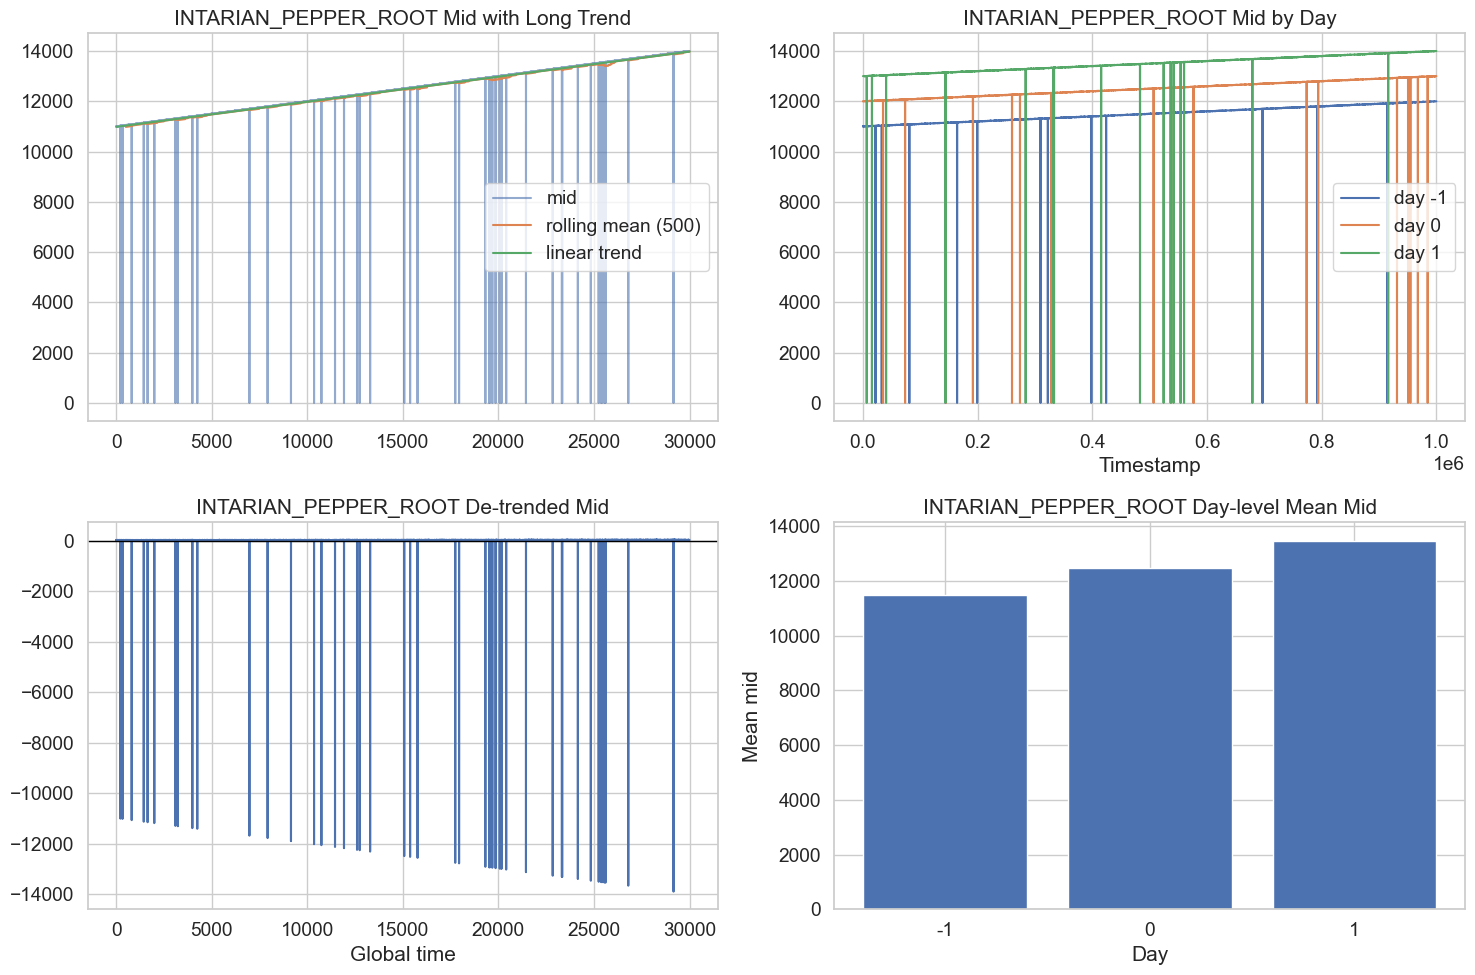

INTARIAN_PEPPER_ROOT linear trend slope/intercept
{'slope': np.float64(0.0998341368148149), 'intercept': np.float64(10982.870448179521)}

INTARIAN_PEPPER_ROOT day summary
       mid_mean   mid_std  mid_min  mid_max  mid_range
day                                                   
-1   11485.1742  504.9108      0.0  12001.5    12001.5
 0   12477.3662  603.2507      0.0  13008.0    13008.0
 1   13478.4572  611.8873      0.0  14003.0    14003.0

De-trended series summary
mean   -3.949875e-12
std     4.957274e+02
min    -1.389393e+04
max     3.327392e+01
Name: detrended_mid, dtype: float64


In [87]:
pepper = price_by_product["INTARIAN_PEPPER_ROOT"].copy()
trend_x = pepper["global_time"].to_numpy()
trend_y = pepper["mid"].to_numpy()
trend_coef = np.polyfit(trend_x, trend_y, 1)
pepper["trend_line"] = np.polyval(trend_coef, trend_x)
pepper["detrended_mid"] = pepper["mid"] - pepper["trend_line"]

pepper_day_summary = (
    pepper.groupby("day")
    .agg(mid_mean=("mid", "mean"), mid_std=("mid", "std"), mid_min=("mid", "min"), mid_max=("mid", "max"))
)
pepper_day_summary["mid_range"] = pepper_day_summary["mid_max"] - pepper_day_summary["mid_min"]

rolling_window = 500
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0, 0].plot(pepper["global_time"], pepper["mid"], alpha=0.6, label="mid")
axes[0, 0].plot(pepper["global_time"], pepper["mid"].rolling(rolling_window).mean(), label=f"rolling mean ({rolling_window})")
axes[0, 0].plot(pepper["global_time"], pepper["trend_line"], label="linear trend")
axes[0, 0].set_title("INTARIAN_PEPPER_ROOT Mid with Long Trend")
axes[0, 0].legend()

for day, sub in pepper.groupby("day"):
    axes[0, 1].plot(sub["timestamp"], sub["mid"], label=f"day {day}")
axes[0, 1].set_title("INTARIAN_PEPPER_ROOT Mid by Day")
axes[0, 1].set_xlabel("Timestamp")
axes[0, 1].legend()

axes[1, 0].plot(pepper["global_time"], pepper["detrended_mid"])
axes[1, 0].axhline(0, color="black", linewidth=1)
axes[1, 0].set_title("INTARIAN_PEPPER_ROOT De-trended Mid")
axes[1, 0].set_xlabel("Global time")

axes[1, 1].bar(pepper_day_summary.index.astype(str), pepper_day_summary["mid_mean"])
axes[1, 1].set_title("INTARIAN_PEPPER_ROOT Day-level Mean Mid")
axes[1, 1].set_xlabel("Day")
axes[1, 1].set_ylabel("Mean mid")
plt.tight_layout()
plt.show()

print("INTARIAN_PEPPER_ROOT linear trend slope/intercept")
print({"slope": trend_coef[0], "intercept": trend_coef[1]})
print("\nINTARIAN_PEPPER_ROOT day summary")
print(pepper_day_summary.round(4))
print("\nDe-trended series summary")
print(pepper["detrended_mid"].agg(["mean", "std", "min", "max"]))


### Interpretation
- If the long rolling mean and fitted trend both move over time, that is strong evidence against a truly constant value.
- If the de-trended series looks much more stable than the raw series, then a slow-moving baseline is likely part of the price process.
- If day-level means differ sharply, that suggests the process may include regime shifts or level resets in addition to within-day noise.
- Strategy intuition: a slow-changing baseline weakens naive constant-fair-value market making and suggests adapting quotes to the evolving level.


### Purpose
- Compare ordinary mid with wall-based mid for each product.
- Check whether deeper visible liquidity carries extra information beyond the best bid and ask.

### Expected Result
- If wall-based mid closely tracks future price better than ordinary mid, it may contain predictive information.
- If wall-based mid behaves similarly to ordinary mid, it likely adds little incremental signal.

### Intuition
- The largest displayed size can act like a stronger reference level than the best quote alone.
- This matters most when one side of the book is thin or when large visible orders anchor short-term price movement.

### Steps
1. Identify the largest visible bid and ask levels.
2. Build a wall-based mid.
3. Compare wall mid against ordinary mid visually.
4. Use the comparison as a signal-screening step rather than a final proof.


# 9. Trade Data Analysis

We now analyze trade data for both `INTARIAN_PEPPER_ROOT` and `ASH_COATED_OSMIUM`.

The goal is to inspect:
- who is trading,
- how much volume prints in each product,
- whether trades tend to happen above or below the quoted mid,
- and whether bursts of trading line up with price moves.


   timestamp  buyer  seller  ...    price quantity  day
0          0    NaN     NaN  ...   9982.0        6   -1
1       3600    NaN     NaN  ...  10001.0        3   -1
2       4200    NaN     NaN  ...  10002.0        2   -1
3       4400    NaN     NaN  ...  11010.0        5   -1
4       5000    NaN     NaN  ...  10996.0        5   -1

[5 rows x 8 columns]

=== INTARIAN_PEPPER_ROOT ===
trades: 2988
total quantity: 15099
avg trade price: 12535.994
avg quoted mid: 12509.0676
avg trade-mid: 26.9264
avg absolute trade-mid: 912.8253
Top buyers:
buyer
UNKNOWN    2988
Name: count, dtype: int64
Top sellers:
seller
UNKNOWN    2988
Name: count, dtype: int64
Correlation between timestamp-level volume and avg trade-mid:
                 quantity  trade_minus_mid
quantity         1.000000         0.141202
trade_minus_mid  0.141202         1.000000

=== ASH_COATED_OSMIUM ===
trades: 4185
total quantity: 21381
avg trade price: 10000.6509
avg quoted mid: 9991.2535
avg trade-mid: 9.3974
avg absolute tra

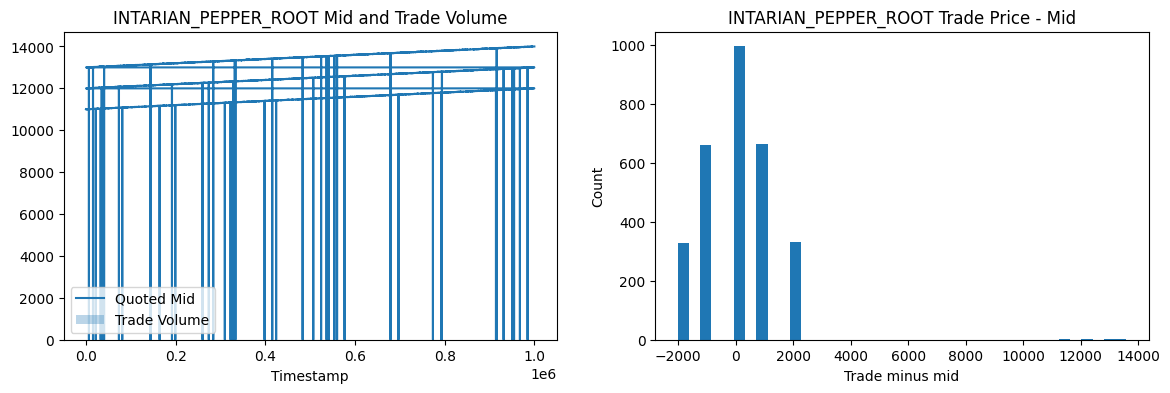

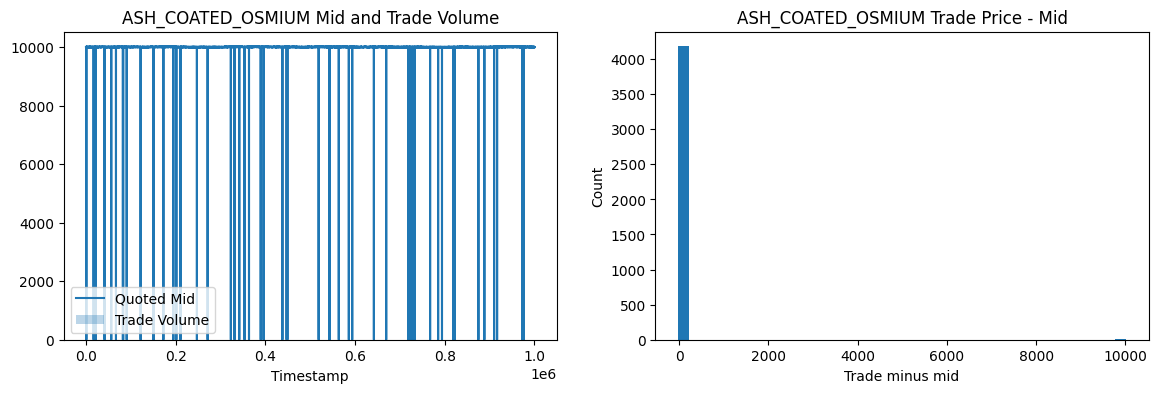

In [105]:
print(trades.head())
PRODUCTS = ["INTARIAN_PEPPER_ROOT", "ASH_COATED_OSMIUM"]

for product in PRODUCTS:
    trade_df = trade_by_product[product].copy()
    price_df = price_by_product[product][["timestamp", "mid", "spread"]].copy()

    merged = trade_df.merge(price_df, on="timestamp", how="left")
    merged["notional"] = merged["price"] * merged["quantity"]
    merged["trade_minus_mid"] = merged["price"] - merged["mid"]
    merged["trade_minus_mid_bps"] = 10000 * merged["trade_minus_mid"] / merged["mid"]

    print(f"\n=== {product} ===")
    print("trades:", len(merged))
    print("total quantity:", merged["quantity"].sum())
    print("avg trade price:", round(merged["price"].mean(), 4))
    print("avg quoted mid:", round(merged["mid"].mean(), 4))
    print("avg trade-mid:", round(merged["trade_minus_mid"].mean(), 4))
    print("avg absolute trade-mid:", round(merged["trade_minus_mid"].abs().mean(), 4))

    volume_by_time = merged.groupby("timestamp", as_index=False)["quantity"].sum()
    signed_price = merged.groupby("timestamp", as_index=False)["trade_minus_mid"].mean()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(price_df["timestamp"], price_df["mid"], label="Quoted Mid")
    axes[0].bar(volume_by_time["timestamp"], volume_by_time["quantity"], alpha=0.3, label="Trade Volume")
    axes[0].set_title(f"{product} Mid and Trade Volume")
    axes[0].set_xlabel("Timestamp")
    axes[0].legend()

    axes[1].hist(merged["trade_minus_mid"].dropna(), bins=40)
    axes[1].set_title(f"{product} Trade Price - Mid")
    axes[1].set_xlabel("Trade minus mid")
    axes[1].set_ylabel("Count")
    plt.show()

    if "buyer" in merged.columns:
        buyer_counts = merged["buyer"].fillna("UNKNOWN").value_counts().head()
        seller_counts = merged["seller"].fillna("UNKNOWN").value_counts().head()
        print("Top buyers:")
        print(buyer_counts)
        print("Top sellers:")
        print(seller_counts)

    print("Correlation between timestamp-level volume and avg trade-mid:")
    joined = volume_by_time.merge(signed_price, on="timestamp", how="inner")
    print(joined[["quantity", "trade_minus_mid"]].corr())



=== Price/Trade Linkage: INTARIAN_PEPPER_ROOT ===
                trade_count  total_quantity  mid_diff  next_mid_diff    spread
trade_count        1.000000        0.954841  0.003661       0.003611 -0.199877
total_quantity     0.954841        1.000000  0.002744       0.004213 -0.205076
mid_diff           0.003661        0.002744  1.000000      -0.510638 -0.003715
next_mid_diff      0.003611        0.004213 -0.510638       1.000000  0.004219
spread            -0.199877       -0.205076 -0.003715       0.004219  1.000000


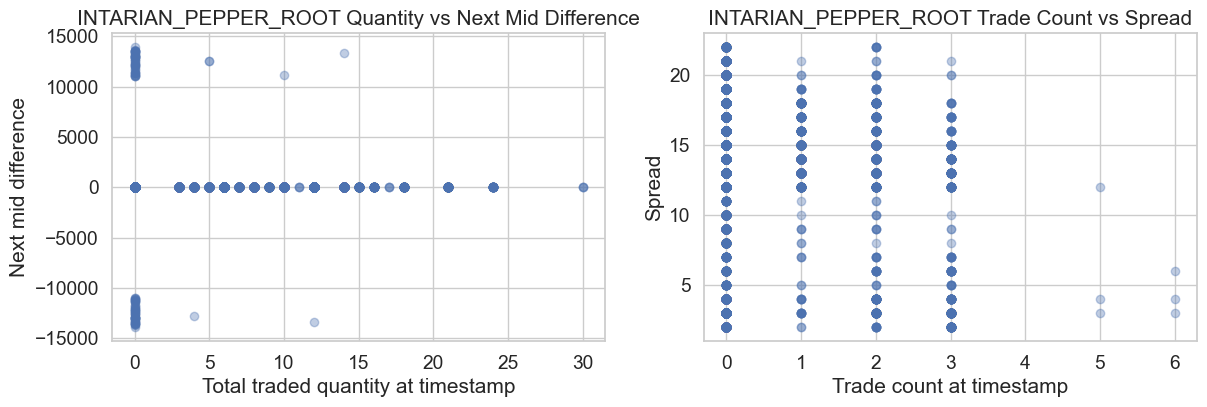


=== Price/Trade Linkage: ASH_COATED_OSMIUM ===
                trade_count  total_quantity  mid_diff  next_mid_diff    spread
trade_count        1.000000        0.923244  0.002068      -0.001062 -0.004956
total_quantity     0.923244        1.000000  0.003262      -0.003310  0.006590
mid_diff           0.002068        0.003262  1.000000      -0.499995 -0.002855
next_mid_diff     -0.001062       -0.003310 -0.499995       1.000000  0.003572
spread            -0.004956        0.006590 -0.002855       0.003572  1.000000


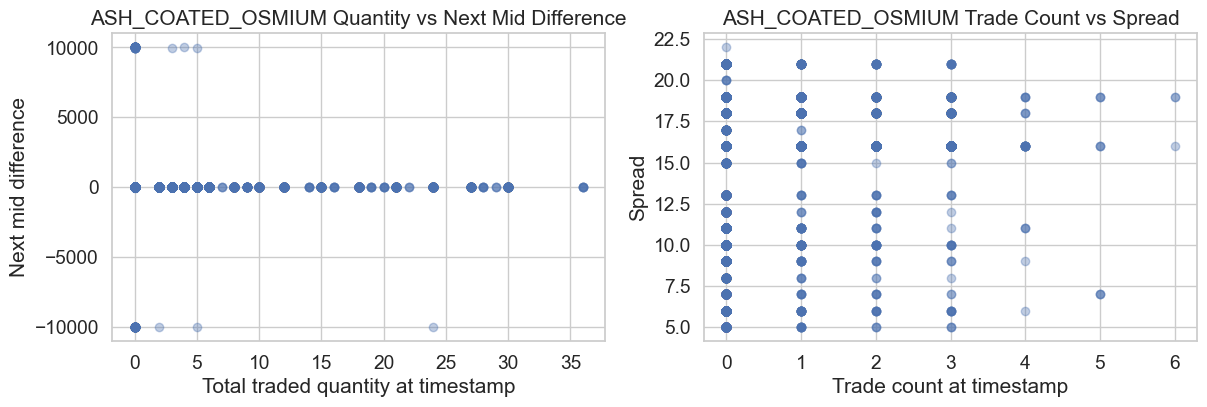

In [89]:
# Price + trade linkage: does heavier trading line up with the next move?
for product in PRODUCTS:
    price_df = price_by_product[product][["timestamp", "mid", "mid_diff", "spread"]].copy()
    trade_df = trade_by_product[product].copy()

    trade_summary = (
        trade_df.groupby("timestamp", as_index=False)
        .agg(trade_count=("price", "size"), total_quantity=("quantity", "sum"), avg_trade_price=("price", "mean"))
    )

    joined = price_df.merge(trade_summary, on="timestamp", how="left").fillna({
        "trade_count": 0,
        "total_quantity": 0,
    })
    joined["next_mid_diff"] = joined["mid"].shift(-1) - joined["mid"]
    joined["trade_count"] = joined["trade_count"].astype(int)

    print(f"\n=== Price/Trade Linkage: {product} ===")
    print(joined[["trade_count", "total_quantity", "mid_diff", "next_mid_diff", "spread"]].corr())

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].scatter(joined["total_quantity"], joined["next_mid_diff"], alpha=0.35)
    axes[0].set_title(f"{product} Quantity vs Next Mid Difference")
    axes[0].set_xlabel("Total traded quantity at timestamp")
    axes[0].set_ylabel("Next mid difference")

    axes[1].scatter(joined["trade_count"], joined["spread"], alpha=0.35)
    axes[1].set_title(f"{product} Trade Count vs Spread")
    axes[1].set_xlabel("Trade count at timestamp")
    axes[1].set_ylabel("Spread")
    plt.show()


### Volume vs `mid_diff` / `next_mid_diff`
- Use `day` and `timestamp` together so trade volume is aligned to the correct price event.
- Check signed `next_mid_diff` to test directional linkage.
- Check `abs(next_mid_diff)` to test whether heavier trading is more associated with move size than with direction.
- A simple regression on `log(1 + total_quantity)` is a useful summary, but it should be read together with scatter plots and binned averages.


=== Volume vs Mid-Diff Linkage: INTARIAN_PEPPER_ROOT ===
                    trade_count  total_quantity  ...  abs_next_mid_diff    spread
trade_count            1.000000    9.555503e-01  ...          -0.010038 -0.196114
total_quantity         0.955550    1.000000e+00  ...          -0.009594 -0.201803
log_total_quantity     0.987648    9.880030e-01  ...          -0.009951 -0.199187
mid_diff               0.013072    1.289004e-02  ...          -0.490081 -0.003715
next_mid_diff         -0.000016    5.240322e-08  ...          -0.000017  0.004220
abs_next_mid_diff     -0.010038   -9.594219e-03  ...           1.000000 -0.004975
spread                -0.196114   -2.018026e-01  ...          -0.004975  1.000000

[7 rows x 7 columns]

Simple regression on signed next move:
next_mid_diff ~ 1 + log_total_quantity, beta=-0.006592, R^2=0.000000
Simple regression on move size:
abs_next_mid_diff ~ 1 + log_total_quantity, beta=-21.774163, R^2=0.000099
Controlled regression on signed next move:
next_m

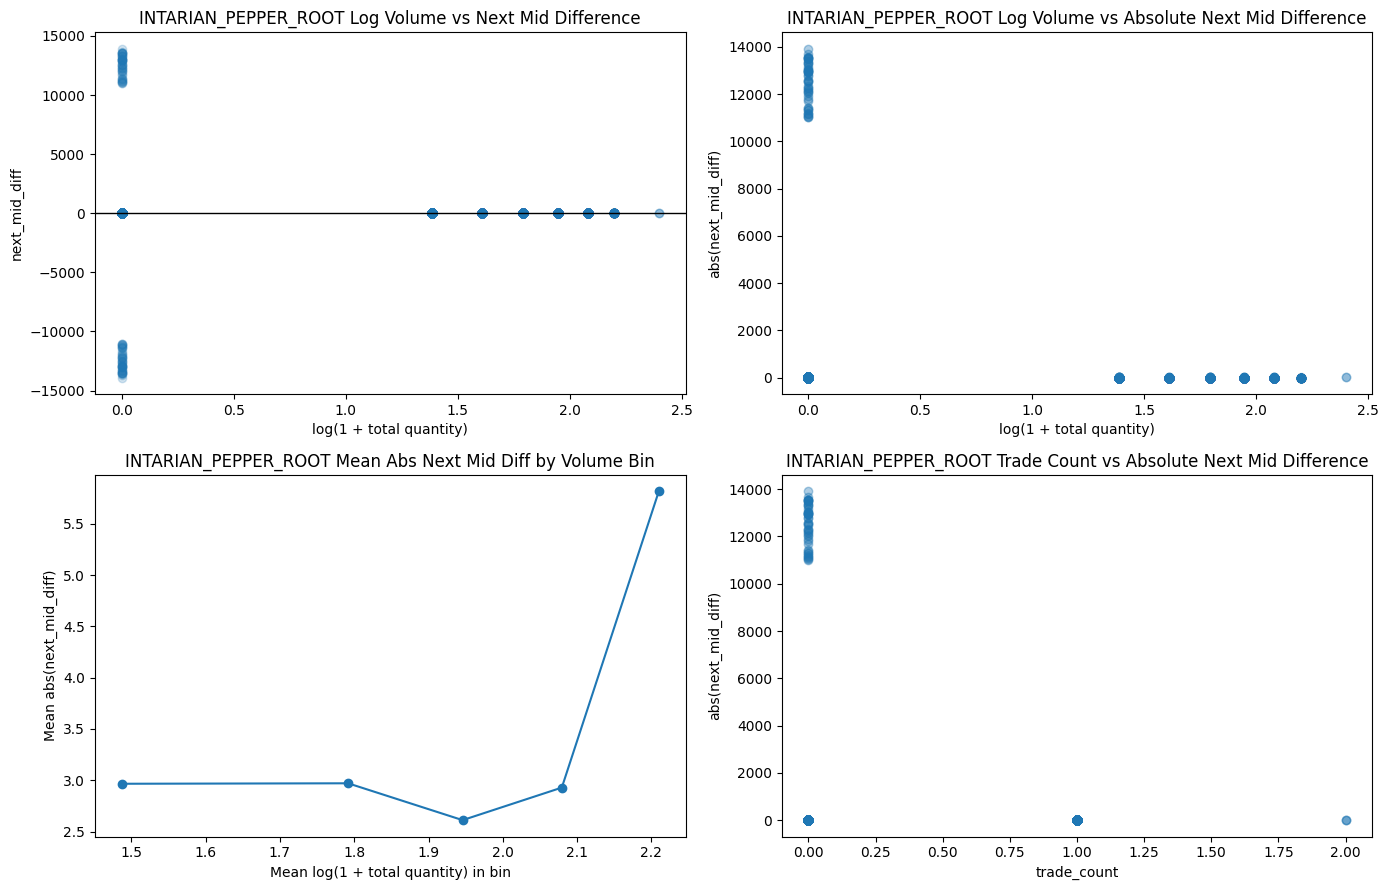

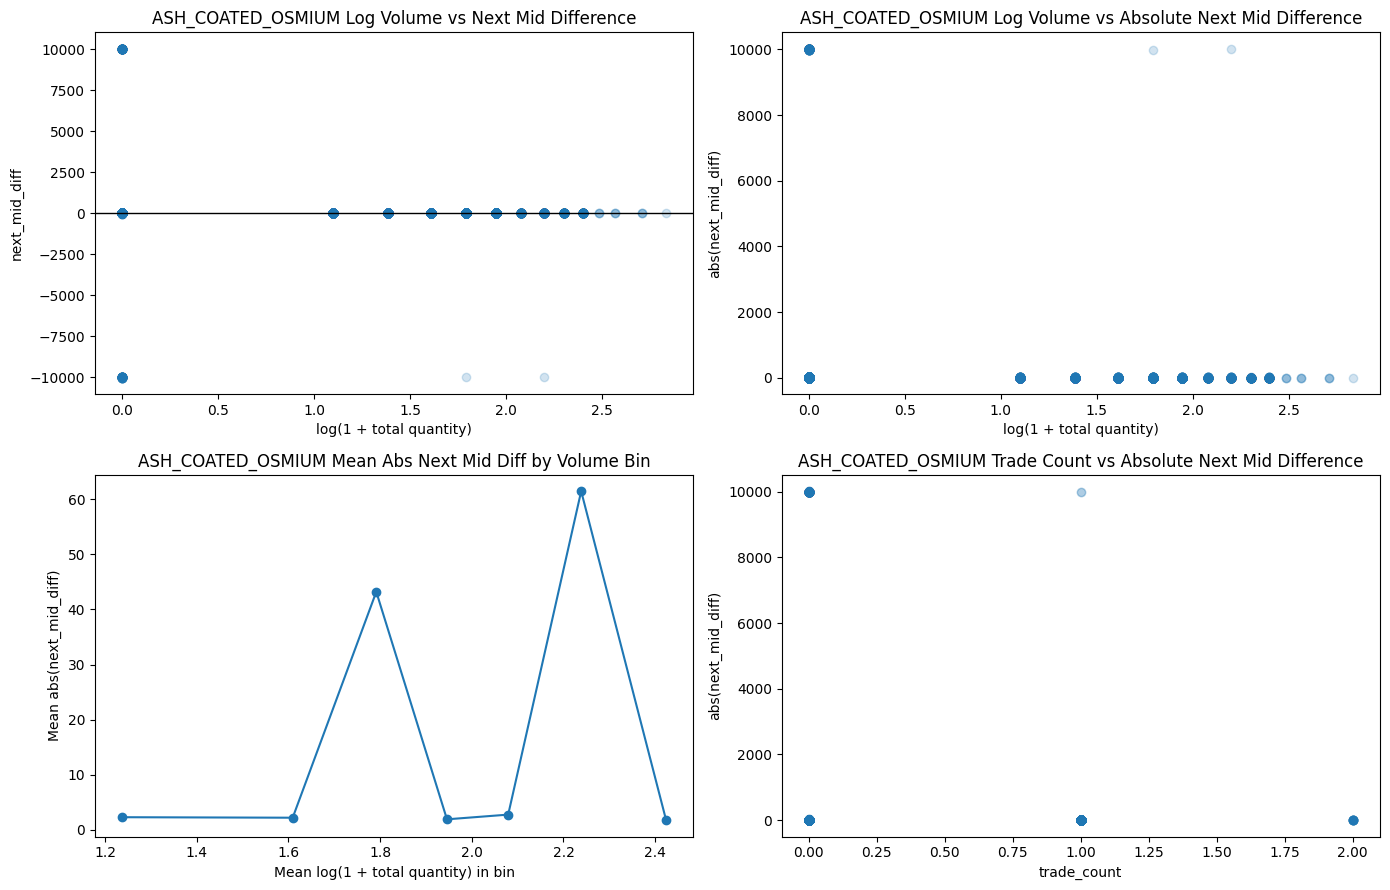

In [106]:
# Day-aware volume / price linkage: direction vs move size

def ols_fit(design_df, y):
    clean = pd.concat([design_df, y.rename("target")], axis=1)
    clean = clean.replace([np.inf, -np.inf], np.nan).dropna()

    if clean.empty:
        return np.full(design_df.shape[1] + 1, np.nan), np.nan

    X = np.column_stack([np.ones(len(clean)), clean[design_df.columns].to_numpy(dtype=float)])
    y_vec = clean["target"].to_numpy(dtype=float)
    beta = np.linalg.pinv(X.T @ X) @ (X.T @ y_vec)
    fitted = X @ beta
    resid = y_vec - fitted
    ss_res = float((resid**2).sum())
    ss_tot = float(((y_vec - y_vec.mean())**2).sum())
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return beta, r2

for product in PRODUCTS:
    price_df = price_by_product[product][["day", "timestamp", "mid", "mid_diff", "spread"]].copy()
    trade_df = trade_by_product[product].copy()

    trade_summary = (
        trade_df.groupby(["day", "timestamp"], as_index=False)
        .agg(
            trade_count=("price", "size"),
            total_quantity=("quantity", "sum"),
            avg_trade_price=("price", "mean"),
        )
    )

    joined = price_df.merge(trade_summary, on=["day", "timestamp"], how="left").fillna({
        "trade_count": 0,
        "total_quantity": 0,
    })
    joined["trade_count"] = joined["trade_count"].astype(int)
    joined["next_mid_diff"] = joined.groupby("day")["mid"].shift(-1) - joined["mid"]
    joined["abs_mid_diff"] = joined["mid_diff"].abs()
    joined["abs_next_mid_diff"] = joined["next_mid_diff"].abs()
    joined["log_total_quantity"] = np.log1p(joined["total_quantity"])

    analysis = joined.dropna(subset=["mid_diff", "next_mid_diff", "abs_next_mid_diff"]).copy()

    print(f"\n=== Volume vs Mid-Diff Linkage: {product} ===")
    print(
        analysis[[
            "trade_count",
            "total_quantity",
            "log_total_quantity",
            "mid_diff",
            "next_mid_diff",
            "abs_next_mid_diff",
            "spread",
        ]].corr()
    )

    simple_signed_beta, simple_signed_r2 = ols_fit(
        analysis[["log_total_quantity"]],
        analysis["next_mid_diff"],
    )
    simple_abs_beta, simple_abs_r2 = ols_fit(
        analysis[["log_total_quantity"]],
        analysis["abs_next_mid_diff"],
    )

    controlled_design = analysis[["log_total_quantity", "spread", "abs_mid_diff"]].copy()
    day_dummies = pd.get_dummies(analysis["day"], prefix="day", drop_first=True, dtype=float)
    if not day_dummies.empty:
        controlled_design = pd.concat([controlled_design, day_dummies], axis=1)

    controlled_signed_beta, controlled_signed_r2 = ols_fit(controlled_design, analysis["next_mid_diff"])
    controlled_abs_beta, controlled_abs_r2 = ols_fit(controlled_design, analysis["abs_next_mid_diff"])

    print("\nSimple regression on signed next move:")
    print(f"next_mid_diff ~ 1 + log_total_quantity, beta={simple_signed_beta[1]:.6f}, R^2={simple_signed_r2:.6f}")
    print("Simple regression on move size:")
    print(f"abs_next_mid_diff ~ 1 + log_total_quantity, beta={simple_abs_beta[1]:.6f}, R^2={simple_abs_r2:.6f}")
    print("Controlled regression on signed next move:")
    print(f"next_mid_diff ~ 1 + log_total_quantity + spread + abs_mid_diff + day FE, beta={controlled_signed_beta[1]:.6f}, R^2={controlled_signed_r2:.6f}")
    print("Controlled regression on move size:")
    print(f"abs_next_mid_diff ~ 1 + log_total_quantity + spread + abs_mid_diff + day FE, beta={controlled_abs_beta[1]:.6f}, R^2={controlled_abs_r2:.6f}")

    nonzero_volume = analysis[analysis["total_quantity"] > 0].copy()
    if len(nonzero_volume) >= 10 and nonzero_volume["log_total_quantity"].nunique() > 1:
        nonzero_volume["volume_bin"] = pd.qcut(
            nonzero_volume["log_total_quantity"],
            q=min(10, nonzero_volume["log_total_quantity"].nunique()),
            duplicates="drop",
        )
        binned = (
            nonzero_volume.groupby("volume_bin", observed=False)
            .agg(
                mean_log_quantity=("log_total_quantity", "mean"),
                mean_abs_next_mid_diff=("abs_next_mid_diff", "mean"),
            )
            .reset_index(drop=True)
        )
    else:
        binned = pd.DataFrame(columns=["mean_log_quantity", "mean_abs_next_mid_diff"])

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes[0, 0].scatter(analysis["log_total_quantity"], analysis["next_mid_diff"], alpha=0.2)
    axes[0, 0].axhline(0, color="black", linewidth=1)
    axes[0, 0].set_title(f"{product} Log Volume vs Next Mid Difference")
    axes[0, 0].set_xlabel("log(1 + total quantity)")
    axes[0, 0].set_ylabel("next_mid_diff")

    axes[0, 1].scatter(analysis["log_total_quantity"], analysis["abs_next_mid_diff"], alpha=0.2)
    axes[0, 1].set_title(f"{product} Log Volume vs Absolute Next Mid Difference")
    axes[0, 1].set_xlabel("log(1 + total quantity)")
    axes[0, 1].set_ylabel("abs(next_mid_diff)")

    if len(binned) > 0:
        axes[1, 0].plot(binned["mean_log_quantity"], binned["mean_abs_next_mid_diff"], marker="o")
    axes[1, 0].set_title(f"{product} Mean Abs Next Mid Diff by Volume Bin")
    axes[1, 0].set_xlabel("Mean log(1 + total quantity) in bin")
    axes[1, 0].set_ylabel("Mean abs(next_mid_diff)")

    axes[1, 1].scatter(analysis["trade_count"], analysis["abs_next_mid_diff"], alpha=0.2)
    axes[1, 1].set_title(f"{product} Trade Count vs Absolute Next Mid Difference")
    axes[1, 1].set_xlabel("trade_count")
    axes[1, 1].set_ylabel("abs(next_mid_diff)")
    plt.tight_layout()
    plt.show()


### Reading the result
- Near-zero correlation or regression slope for signed `next_mid_diff` means volume alone is not a strong directional predictor.
- A positive relationship with `abs(next_mid_diff)` means heavier trading is more associated with short-term move magnitude than with sign.
- If the binned curve slopes upward while the signed regression stays flat, that is classic "volume links to volatility, not direction" behavior.
- To test true directional pressure, you would need signed order flow, not just total traded quantity.

# 10. Initial Conclusions

### Steps
1. State the best-supported description for `ASH_COATED_OSMIUM`.
2. State the best-supported description for `INTARIAN_PEPPER_ROOT`.
3. Reference the sections that support each conclusion.
4. Translate the findings into strategy implications.

## `ASH_COATED_OSMIUM`
- Does the price stay near a stable center across all three days?
- Do the rolling mean and day-level summary support a mostly flat process?
- Do the `mid_diff` autocorrelations support random walk, or do they look more mean reverting?
- Is this product better described as flat-with-noise, random walk, or weak mean reversion?
- What kind of strategy does that suggest?

## `INTARIAN_PEPPER_ROOT`
- Does the price behave like a constant fair value, or does its baseline move over time?
- Do the long rolling mean and fitted time trend support a slow-changing process?
- Are the changes smooth, or do they look more like step changes across days or subperiods?
- After de-trending, does the residual series look much more stable?
- What kind of strategy does that suggest?
